# 1-2회차 실습 | 펭귄 데이터로 규칙 만들기

아직 모델 배운 거 없음. 오늘은 눈이랑 손으로만 종을 맞춰봄.

목표는 정확도를 올리는 게 아니라, **어디서 막히는지** 직접 느껴보는 거임.


---
## 실습 규칙

1. 코드 치기 전에 한글로 먼저 설계할 것 (키보드 금지)
2. `[예측]` 있으면 실행 전에 먼저 적을 것 — 틀려도 됨, 오히려 틀려야 배움
3. 결과 나오면 "내 예측이랑 뭐가 달랐나" 한 줄 적을 것

> 질문 -> 예측 -> 실행 -> 증거 -> 더 나은 질문


---
## Part 0. 준비

Iris는 결측치도 없고 품종별 개수도 딱 50개씩 균등함. 너무 깨끗함.

그래서 오늘은 진짜 현실 데이터인 **펭귄(Palmer Penguins)** 데이터로 감.

- 측정 못 한 애들 있음 (결측치)
- 종별 개수 안 맞음 (불균형)
- 넣으면 점수는 오르는데 넣어도 되는지 애매한 컬럼도 있음


In [5]:
# 오늘 실습에서 쓸 도구들을 한 번에 불러옵니다.
import numpy as np              # 숫자 계산 (조건에 따라 값 고르기 등)
import pandas as pd             # 표 형태 데이터 다루기
import seaborn as sns           # 펭귄 데이터를 불러오는 용도로만 사용
import matplotlib.pyplot as plt # 그래프 그리기

# 버전을 기록해 둡니다. 나중에 결과가 다르게 나올 때 원인을 찾는 단서가 됩니다.
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"seaborn    : {sns.__version__}")


numpy      : 2.5.1
pandas     : 3.0.5
seaborn    : 0.13.2


In [6]:
# 그래프 제목에 한글을 쓰면, 폰트가 없을 때 네모(□□□)로 깨집니다.
# 운영체제마다 한글 폰트 이름이 다르기 때문에, 있는 것을 자동으로 찾아 씁니다.
import matplotlib.font_manager as fm

# 후보 폰트: 맥 / 윈도우 / 리눅스(Colab) 순서
candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]

# 현재 컴퓨터에 설치된 폰트 이름을 모두 모읍니다.
installed = {f.name for f in fm.fontManager.ttflist}

# 후보 중 실제로 설치된 첫 번째 폰트를 선택합니다.
chosen = next((c for c in candidates if c in installed), None)

if chosen:
    plt.rcParams["font.family"] = chosen
    print(f"한글 폰트 설정 완료: {chosen}")
else:
    # 하나도 없으면 한글이 깨집니다. Colab이라면 아래 주석을 풀고 설치하세요.
    # !apt-get install -y fonts-nanum > /dev/null && fc-cache -fv
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 한글 폰트를 쓰면 축의 마이너스 기호가 깨지는 문제가 있어 함께 꺼 줍니다.
plt.rcParams["axes.unicode_minus"] = False


한글 폰트 설정 완료: Malgun Gothic


In [7]:
# seaborn에 내장된 예제 데이터 목록에서 펭귄 데이터를 가져옵니다.
# 주의: 이 함수는 인터넷에서 데이터를 내려받습니다.
#       오프라인이거나 회사망에서 막히면 아래 except 안내를 참고하세요.
try:
    peng_raw = sns.load_dataset("penguins")
    print("데이터 로드 성공")
except Exception as e:
    print("데이터를 내려받지 못했습니다:", e)
    print("penguins.csv 파일을 받아 같은 폴더에 두고 아래 줄을 쓰세요.")
    print('peng_raw = pd.read_csv("penguins.csv")')

# 앞의 5줄만 눈으로 확인합니다. 데이터를 만나면 항상 먼저 하는 일입니다.
peng_raw.head()


데이터 로드 성공


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 컬럼 설명

| 컬럼 | 뜻 | 종류 |
|------|-----|------|
| `species` | 펭귄 종 (Adelie / Chinstrap / Gentoo) | 문자 |
| `island` | 관측된 섬 (Biscoe / Dream / Torgersen) | 문자 |
| `bill_length_mm` | 부리 길이 (mm) | 숫자 |
| `bill_depth_mm` | 부리 두께 (mm) | 숫자 |
| `flipper_length_mm` | 물갈퀴 길이 (mm) | 숫자 |
| `body_mass_g` | 몸무게 (g) | 숫자 |
| `sex` | 성별 (Male / Female) | 문자 |

오늘 맞출 정답(Target)은 `species`. 나머지 측정값 4개가 특성(Feature)임.


---
## Part 1. 데이터 정체 파악

### Q1. 데이터 크기 확인

몇 마리, 컬럼 몇 개인지 확인할 것.

**[예측]**
- 행 수: ______
- 열 수: ______


In [8]:
# .shape 는 (행 개수, 열 개수) 를 튜플로 돌려줍니다.
print(f"데이터 크기: {peng_raw.shape}")
print(f"  -> 펭귄 {peng_raw.shape[0]}마리, 컬럼 {peng_raw.shape[1]}개")


데이터 크기: (344, 7)
  -> 펭귄 344마리, 컬럼 7개


### Q2. 컬럼 타입 확인

문자 컬럼 vs 숫자 컬럼 구분하는 거임. 모델은 문자를 그대로 못 먹음.

**[예측]** 문자 컬럼 몇 개일 것 같음? ______


In [5]:
# .info() 는 컬럼 이름, 비어있지 않은 값의 개수, 타입을 한 번에 보여줍니다.
peng_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### Q3. 결측치 개수 세기

**[예측]**
- `bill_length_mm`: ______
- `sex`: ______


In [11]:
# .isnull() 은 각 칸이 비었으면 True, 아니면 False 인 표를 만듭니다.
# 여기에 .sum() 을 붙이면 컬럼별로 True 의 개수(=결측 개수)를 세어 줍니다.
print("컬럼별 결측치 개수:")
print(peng_raw.isnull().sum())

# 전체 칸 중 결측이 차지하는 비율도 함께 봅니다.
total_cells = peng_raw.shape[0] * peng_raw.shape[1]
missing_ratio = peng_raw.isnull().sum().sum() / total_cells * 100
print(f"\n전체 결측 비율: {missing_ratio:.2f}%")


컬럼별 결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

전체 결측 비율: 0.79%


### Q4. 결측치 있는 행 직접 까보기

개수만 세면 놓치는 거 있음. 진짜로 그 행을 열어봐야 함.

**[예측]** 측정값 4개가 다 비어있는 애가 있을까, 아니면 하나씩만 비었을까?


In [12]:
# 측정값 컬럼 4개의 이름을 리스트로 묶어 둡니다. 앞으로 계속 씁니다.
meas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# peng_raw[meas].isnull()        -> 측정값 4칸이 비었는지 True/False 표
# .all(axis=1)                   -> 한 행에서 4칸이 '모두' True인지 (axis=1은 가로 방향)
mask_all_missing = peng_raw[meas].isnull().all(axis=1)

print(f"측정값 4개가 모두 비어있는 행: {mask_all_missing.sum()}개")
display(peng_raw[mask_all_missing])

# sex 만 비어있고 측정값은 멀쩡한 행도 세어 봅니다.
# .notnull().all(axis=1) -> 측정값 4칸이 모두 채워져 있는 행
mask_sex_only = peng_raw["sex"].isnull() & peng_raw[meas].notnull().all(axis=1)
print(f"\n측정값은 멀쩡한데 sex만 비어있는 행: {mask_sex_only.sum()}개")


측정값 4개가 모두 비어있는 행: 2개


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN



측정값은 멀쩡한데 sex만 비어있는 행: 9개


### 종 분류용 데이터 확정

측정값 기준으로만 결측 제거함.

In [13]:
# 종 분류용 데이터를 만듭니다.
# subset=meas -> 측정값 4개 중 하나라도 비면 그 행을 버립니다.
#                sex가 비어 있는 것은 신경 쓰지 않습니다.
peng = peng_raw.dropna(subset=meas).reset_index(drop=True)

print(f"원본        : {peng_raw.shape[0]}마리")
print(f"측정값 결측 제거 후: {peng.shape[0]}마리")
print(f"버린 펭귄   : {peng_raw.shape[0] - peng.shape[0]}마리")

# reset_index(drop=True) 는 행을 버리면서 생긴 번호 구멍을 다시 0부터 매겨 줍니다.


원본        : 344마리
측정값 결측 제거 후: 342마리
버린 펭귄   : 2마리


In [22]:
counts = peng["species"].value_counts()
ratios = peng["species"].value_counts(normalize=True)
display(counts)
display(counts.index)
display(counts.values)

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

Index(['Adelie', 'Gentoo', 'Chinstrap'], dtype='str', name='species')

array([151, 123,  68])

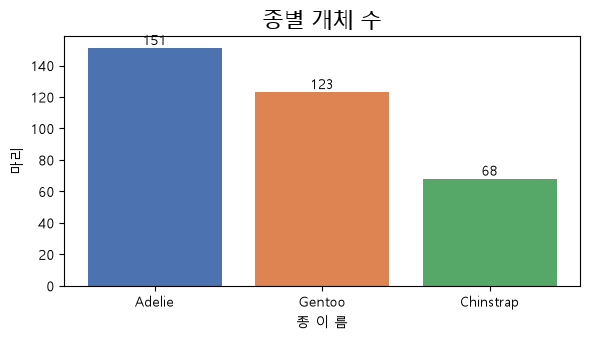

In [ ]:
import matplotlib.pyplot as plt # 그래프 그리기
##폰트 준비


# 막대그래프로
plt.figure(figsize=(6, 3.5))
plt.bar( ['Adelie', 'Gentoo', 'Chinstrap'], [151, 123, 68], color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("종별 개체 수", size=15)
plt.ylabel("마리")
plt.xlabel("종 이 름")

# 막대 위에 숫자를 직접 적어 주면 읽기 편합니다.
for i, v in enumerate([151, 123, 68]):  #enumerate() 인덱스 i와 값 v를 동시에 꺼내주는 함수
    plt.text(i, v + 2, str(v), ha="center") 
    #plt.text(x좌표, y좌표, 표시할 문자열, 옵션) #
    # i: x축 위치  
    # v + 2: y축 위치입니다. 값 v보다 조금 높은 곳에 글자를 찍기
    # str(v): 실제로 그래프에 적힐 내용
    # ha="center": 수평 정렬

plt.tight_layout()  # 제목, 축 레이블, 눈금, 서브플롯 간격이 서로 겹치지 않도록 레이아웃을 자동으로 조정
plt.show()

### Q5. species 분포 확인

**[예측]** 가장 많은 종은 전체의 몇 %일 것 같음? ______%


종별 개체 수:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

종별 비율:
species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.199
Name: proportion, dtype: float64


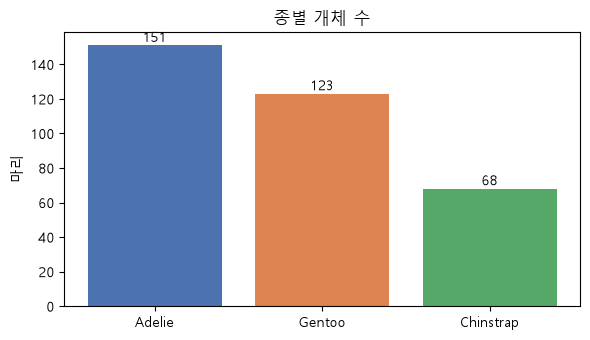

In [14]:
# value_counts() -> 값별 개수, normalize=True 를 주면 비율
counts = peng["species"].value_counts()
ratios = peng["species"].value_counts(normalize=True)

print("종별 개체 수:")
print(counts)
print("\n종별 비율:")
print(ratios.round(3))

# 막대그래프로도 확인합니다.
plt.figure(figsize=(6, 3.5))
plt.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("종별 개체 수")
plt.ylabel("마리")
# 막대 위에 숫자를 직접 적어 주면 읽기 편합니다.
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha="center")
plt.tight_layout()
plt.show()


### Q6. 종별 측정값 평균 비교

**[예측]** 4개 측정값 중 종 구별에 제일 쓸모있어 보이는 거 하나 골라볼 것. 왜 그렇게 생각함?


In [15]:
# groupby("species") -> 종별로 묶고, [meas] 로 측정값만 골라 평균을 냅니다.
group_mean = peng.groupby("species")[meas].mean().round(1)
print("종별 평균:")
display(group_mean)

# 평균만 보면 위험합니다. 퍼진 정도(표준편차)도 함께 봐야
# "평균은 다른데 실제로는 겹치는" 경우를 걸러낼 수 있습니다.
group_std = peng.groupby("species")[meas].std().round(1)
print("\n종별 표준편차(값이 얼마나 퍼져 있는가):")
display(group_std)


종별 평균:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.8,18.3,190.0,3700.7
Chinstrap,48.8,18.4,195.8,3733.1
Gentoo,47.5,15.0,217.2,5076.0



종별 표준편차(값이 얼마나 퍼져 있는가):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,2.7,1.2,6.5,458.6
Chinstrap,3.3,1.1,7.1,384.3
Gentoo,3.1,1.0,6.5,504.1


---
## Part 2. 눈으로 보기

### Q7. 산점도로 두 특성 동시에 보기

**[예측]** 세 종이 안 겹치고 갈라질 것 같음, 아니면 계속 겹칠 것 같음?


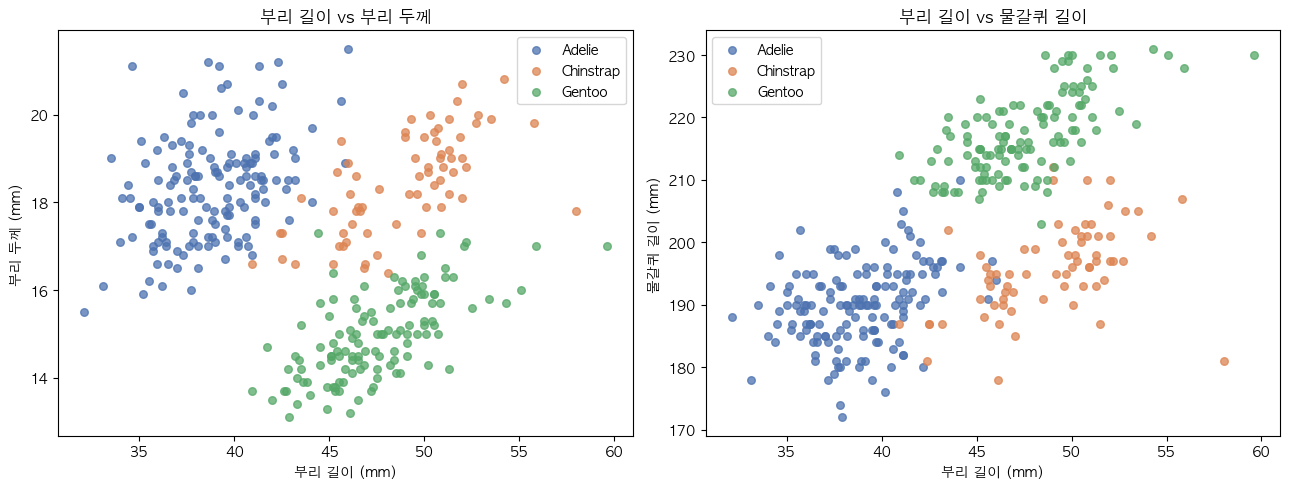

In [11]:
# 종마다 다른 색을 쓰기 위해 색을 미리 정해 둡니다.
colors = {"Adelie": "#4C72B0", "Chinstrap": "#DD8452", "Gentoo": "#55A868"}

# 1행 2열로 그래프 두 개를 나란히 그립니다.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 종별로 데이터를 잘라서, 각각 다른 색으로 점을 찍습니다.
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    sub = peng[peng["species"] == sp]   # 그 종만 골라내기

    # 왼쪽: 부리 길이 vs 부리 두께
    axes[0].scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
                    label=sp, color=colors[sp], alpha=0.75, s=30)

    # 오른쪽: 부리 길이 vs 물갈퀴 길이
    axes[1].scatter(sub["bill_length_mm"], sub["flipper_length_mm"],
                    label=sp, color=colors[sp], alpha=0.75, s=30)

axes[0].set_xlabel("부리 길이 (mm)")
axes[0].set_ylabel("부리 두께 (mm)")
axes[0].set_title("부리 길이 vs 부리 두께")
axes[0].legend()

axes[1].set_xlabel("부리 길이 (mm)")
axes[1].set_ylabel("물갈퀴 길이 (mm)")
axes[1].set_title("부리 길이 vs 물갈퀴 길이")
axes[1].legend()

plt.tight_layout()
plt.show()


### (보조) 상자그림으로 4개 특성 한눈에 비교

상자가 안 겹치는 특성 = 그거 하나로 잘 갈라진다는 뜻임.


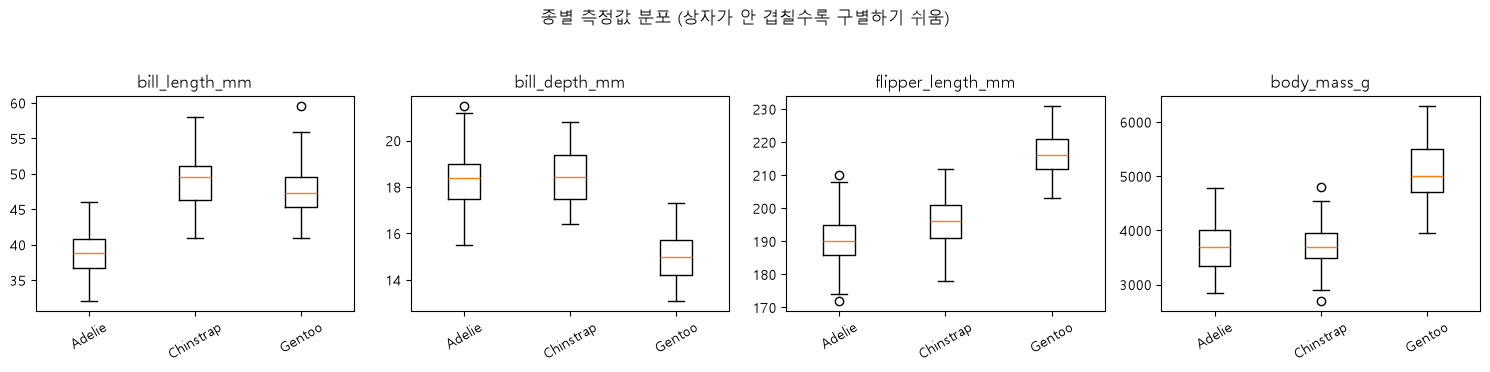

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
species_order = ["Adelie", "Chinstrap", "Gentoo"]

for i, col in enumerate(meas):
    # 종별로 그 컬럼의 값들만 리스트로 모읍니다.
    data_by_species = [peng.loc[peng["species"] == sp, col].values for sp in species_order]

    axes[i].boxplot(data_by_species, tick_labels=species_order)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("종별 측정값 분포 (상자가 안 겹칠수록 구별하기 쉬움)", y=1.05)
plt.tight_layout()
plt.show()


In [17]:
for col in meas:
    print(f"==== {col} ====")
    display(peng.groupby('species')[col].describe()[['min', '25%', '50%', '75%', 'max']])
    print()

==== bill_length_mm ====


,min,25%,50%,75%,max
species,,,,,
Adelie,32.1,36.75,38.80,40.750,46.0
Chinstrap,40.9,46.35,49.55,51.075,58.0
Gentoo,40.9,45.30,47.30,49.550,59.6



==== bill_depth_mm ====


,min,25%,50%,75%,max
species,,,,,
Adelie,15.5,17.5,18.40,19.0,21.5
Chinstrap,16.4,17.5,18.45,19.4,20.8
Gentoo,13.1,14.2,15.00,15.7,17.3



==== flipper_length_mm ====


,min,25%,50%,75%,max
species,,,,,
Adelie,172.0,186.0,190.0,195.0,210.0
Chinstrap,178.0,191.0,196.0,201.0,212.0
Gentoo,203.0,212.0,216.0,221.0,231.0



==== body_mass_g ====


,min,25%,50%,75%,max
species,,,,,
Adelie,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,3950.0,4700.0,5000.0,5500.0,6300.0


---
## Part 3. 내 규칙 만들기

### Q8. 한글로 먼저 설계 (키보드 금지)

측정값 보고 종 맞추는 규칙을 한글로 씀.

```
1단계: 만약 (   )가 (   )보다 (크면/작으면) -> (   ) 이다
2단계: 그렇지 않고 (   )가 (   )보다 (크면/작으면) -> (   ) 이다
3단계: 나머지는 -> (   ) 이다
```

**[내 설계]**
```
1단계:
2단계:
3단계:
```

**[예측]** 정확도 몇 % 나올 것 같음? ______%


### Q9. 한글 설계를 코드로 옮기기

| 한글 | 파이썬 |
|------|--------|
| 만약 ~라면 | `if ~:` |
| 그렇지 않고 ~라면 | `elif ~:` |
| 나머지는 | `else:` |
| ~이다 | `return ~` |


In [13]:
def my_rule(row):
    """펭귄 한 마리(row)를 받아서 종 이름을 돌려주는 함수.

    row 는 표의 한 줄입니다. row["bill_length_mm"] 처럼 값을 꺼내 씁니다.
    """
    # 1단계: 물갈퀴가 길면 Gentoo
    if row["flipper_length_mm"] > 206:
        return "Gentoo"

    # 2단계: 물갈퀴가 짧고, 부리도 짧으면 Adelie
    elif row["bill_length_mm"] < 43:
        return "Adelie"

    # 3단계: 나머지 (물갈퀴 짧고 부리 김) 는 Chinstrap
    else:
        return "Chinstrap"


# .apply(함수, axis=1) -> 표의 모든 행에 함수를 한 번씩 적용합니다.
# axis=1 은 "가로 방향으로, 한 행씩 넘겨라" 라는 뜻입니다.
my_pred = peng.apply(my_rule, axis=1)

# 결과를 원래 표 옆에 붙여서 확인합니다.
check = peng[["species"] + meas].copy()
check["내_예측"] = my_pred
display(check.head(10))


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,내_예측
0,Adelie,39.1,18.7,181.0,3750.0,Adelie
1,Adelie,39.5,17.4,186.0,3800.0,Adelie
2,Adelie,40.3,18.0,195.0,3250.0,Adelie
3,Adelie,36.7,19.3,193.0,3450.0,Adelie
4,Adelie,39.3,20.6,190.0,3650.0,Adelie
5,Adelie,38.9,17.8,181.0,3625.0,Adelie
6,Adelie,39.2,19.6,195.0,4675.0,Adelie
7,Adelie,34.1,18.1,193.0,3475.0,Adelie
8,Adelie,42.0,20.2,190.0,4250.0,Adelie
9,Adelie,37.8,17.1,186.0,3300.0,Adelie


### Q10. 채점하기

정확도 = 맞춘 개수 / 전체 개수

**[예측]** Q8에 적은 숫자 다시 옮겨 적을 것: ______%


In [14]:
# (my_pred == peng["species"]) -> 맞았으면 True, 틀렸으면 False 인 줄
is_correct = (my_pred == peng["species"])

# True 를 1로 세면 맞춘 개수, .mean() 을 쓰면 바로 비율(=정확도)
n_correct = is_correct.sum()
accuracy = is_correct.mean()

print(f"맞춘 개수 : {n_correct} / {len(peng)}")
print(f"정확도    : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()

# 기준선과 비교합니다. 이 비교 없이는 숫자를 해석할 수 없습니다.
baseline = peng["species"].value_counts(normalize=True).max()
print(f"기준선(전부 Adelie로 찍기): {baseline:.4f}  ({baseline*100:.2f}%)")
print(f"내 규칙이 기준선보다      : +{(accuracy-baseline)*100:.2f}%p")


맞춘 개수 : 323 / 342
정확도    : 0.9444  (94.44%)

기준선(전부 Adelie로 찍기): 0.4415  (44.15%)
내 규칙이 기준선보다      : +50.29%p


### Q10-2. 틀린 애들은 누구임

**[예측]** 틀린 애들 중 어느 종이 제일 많을 것 같음? 왜 그렇게 생각함?


In [15]:
# 틀린 행만 골라냅니다.
wrong = peng[~is_correct].copy()
wrong["내_예측"] = my_pred[~is_correct]

print(f"틀린 개체: {len(wrong)}마리")
print("\n실제 종별 오답 수:")
print(wrong["species"].value_counts())

print("\n틀린 개체 상세 (앞 10마리):")
display(wrong[["species", "내_예측", "bill_length_mm", "bill_depth_mm", "flipper_length_mm"]].head(10))


틀린 개체: 19마리

실제 종별 오답 수:
species
Adelie       9
Chinstrap    9
Gentoo       1
Name: count, dtype: int64

틀린 개체 상세 (앞 10마리):


,species,내_예측,bill_length_mm,bill_depth_mm,flipper_length_mm
18,Adelie,Chinstrap,46.0,21.5,194.0
42,Adelie,Chinstrap,44.1,19.7,196.0
72,Adelie,Chinstrap,45.8,18.9,197.0
94,Adelie,Gentoo,40.8,18.9,208.0
98,Adelie,Chinstrap,43.2,18.5,192.0
108,Adelie,Chinstrap,43.2,19.0,197.0
110,Adelie,Chinstrap,45.6,20.3,191.0
128,Adelie,Gentoo,44.1,18.0,210.0
130,Adelie,Chinstrap,43.1,19.2,197.0
171,Chinstrap,Adelie,42.4,17.3,181.0


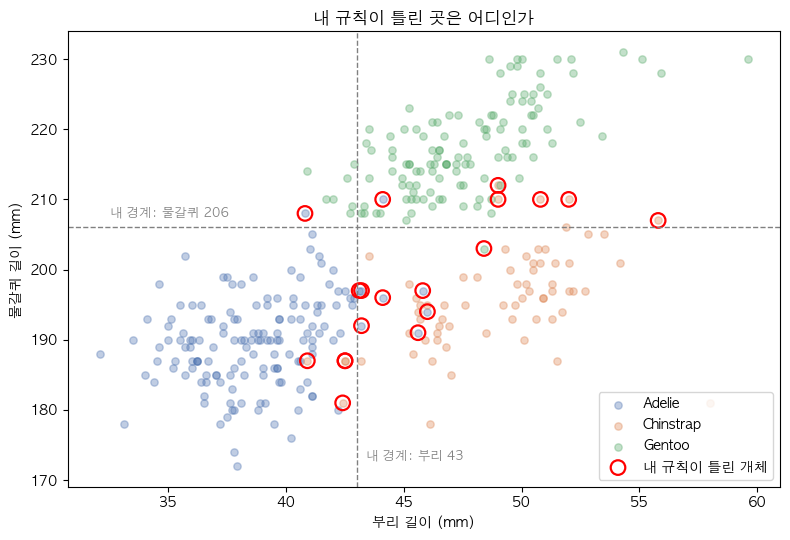

In [16]:
# 틀린 개체가 산점도의 어디에 있는지 눈으로 확인합니다.
plt.figure(figsize=(8, 5.5))

# 먼저 전체를 옅게 그립니다.
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    sub = peng[peng["species"] == sp]
    plt.scatter(sub["bill_length_mm"], sub["flipper_length_mm"],
                label=sp, color=colors[sp], alpha=0.35, s=28)

# 틀린 개체만 빨간 테두리로 덧그립니다.
plt.scatter(wrong["bill_length_mm"], wrong["flipper_length_mm"],
            facecolors="none", edgecolors="red", s=110, linewidths=1.6,
            label="내 규칙이 틀린 개체")

# 내가 그은 경계선 두 개를 그려 봅니다.
plt.axhline(206, color="gray", linestyle="--", linewidth=1)
plt.axvline(43, color="gray", linestyle="--", linewidth=1)
plt.text(32.5, 207.5, "내 경계: 물갈퀴 206", color="gray", fontsize=9)
plt.text(43.4, 173, "내 경계: 부리 43", color="gray", fontsize=9)

plt.xlabel("부리 길이 (mm)")
plt.ylabel("물갈퀴 길이 (mm)")
plt.title("내 규칙이 틀린 곳은 어디인가")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


---
## Part 4. 벽

### Q11. 이번엔 성별 맞춰보기

방법은 똑같음. 그래프 보고, 규칙 만들고, 채점.

먼저 성별 결측 9마리는 제거함.

**[예측]** 성별 맞추기가 종 맞추기보다 쉬울 것 같음, 어려울 것 같음?
내 규칙은 몇 % 나올 것 같음? ______%


In [17]:
# 이번 문제에서는 sex 도 있어야 하므로, sex 결측까지 제거합니다.
peng_sex = peng.dropna(subset=["sex"]).reset_index(drop=True)

print(f"종 분류용 데이터 : {len(peng)}마리")
print(f"성별 예측용 데이터: {len(peng_sex)}마리  (sex 결측 {len(peng)-len(peng_sex)}마리 제거)")
print()
print(peng_sex["sex"].value_counts())

# 기준선: 많은 쪽으로만 찍었을 때의 정확도
base_sex = peng_sex["sex"].value_counts(normalize=True).max()
print(f"\n기준선(전부 Male로 찍기): {base_sex:.4f}")


종 분류용 데이터 : 342마리
성별 예측용 데이터: 333마리  (sex 결측 9마리 제거)

sex
Male      168
Female    165
Name: count, dtype: int64

기준선(전부 Male로 찍기): 0.5045


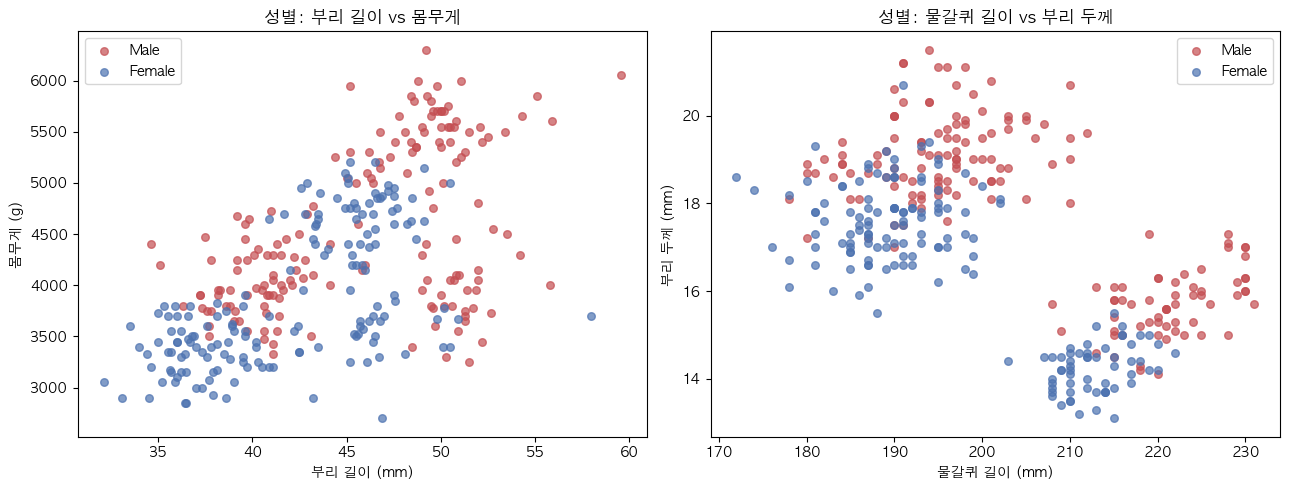

In [18]:
# 성별에 따라 측정값이 다른지, 산점도로 확인합니다.
sex_colors = {"Male": "#C44E52", "Female": "#4C72B0"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sx in ["Male", "Female"]:
    sub = peng_sex[peng_sex["sex"] == sx]
    axes[0].scatter(sub["bill_length_mm"], sub["body_mass_g"],
                    label=sx, color=sex_colors[sx], alpha=0.7, s=30)
    axes[1].scatter(sub["flipper_length_mm"], sub["bill_depth_mm"],
                    label=sx, color=sex_colors[sx], alpha=0.7, s=30)

axes[0].set_xlabel("부리 길이 (mm)"); axes[0].set_ylabel("몸무게 (g)")
axes[0].set_title("성별: 부리 길이 vs 몸무게"); axes[0].legend()

axes[1].set_xlabel("물갈퀴 길이 (mm)"); axes[1].set_ylabel("부리 두께 (mm)")
axes[1].set_title("성별: 물갈퀴 길이 vs 부리 두께"); axes[1].legend()

plt.tight_layout()
plt.show()


### Q12. 성별 규칙 만들고 채점하기

가장 단순한 규칙: "몸무게가 어느 값보다 크면 Male, 아니면 Female"

**[예측]** 기준값 얼마로 잡을 거임? ______g
그때 정확도는 몇 %일 것 같음? ______%


In [19]:
# np.where(조건, 참일때_값, 거짓일때_값) -> 조건에 따라 값을 골라 줍니다.
for threshold in [3700, 4000, 4200, 4500]:
    pred_sex = np.where(peng_sex["body_mass_g"] > threshold, "Male", "Female")
    acc_sex = (pred_sex == peng_sex["sex"]).mean()
    print(f"몸무게 > {threshold}g 이면 Male : 정확도 {acc_sex:.4f}")


몸무게 > 3700g 이면 Male : 정확도 0.7237
몸무게 > 4000g 이면 Male : 정확도 0.6486
몸무게 > 4200g 이면 Male : 정확도 0.6126
몸무게 > 4500g 이면 Male : 정확도 0.5796


시도한 임계값 개수: 160개
최고 성적: 몸무게 > 3700g 일 때 정확도 0.7237
기준선   : 0.5045


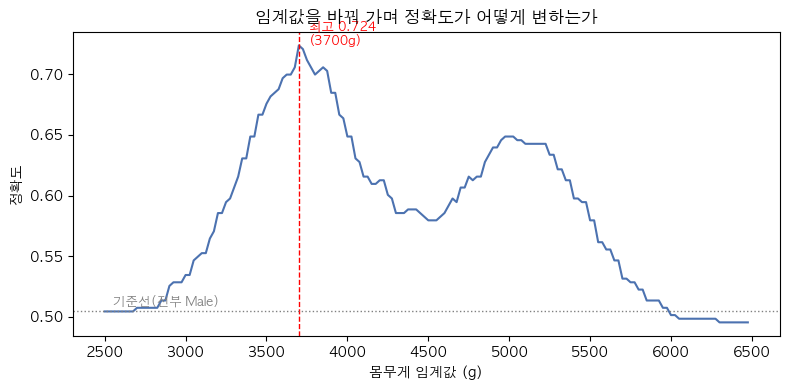

In [20]:
# 임계값을 하나씩 찍어 보는 건 답답합니다.
# 아예 2500g부터 6500g까지 25g 간격으로 '전부' 시도해서 최고점을 찾아봅시다.
thresholds = np.arange(2500, 6500, 25)
accs = []

for t in thresholds:
    pred = np.where(peng_sex["body_mass_g"] > t, "Male", "Female")
    accs.append((pred == peng_sex["sex"]).mean())

accs = np.array(accs)
best_idx = accs.argmax()   # 가장 높은 정확도의 위치
best_t, best_acc = thresholds[best_idx], accs[best_idx]

print(f"시도한 임계값 개수: {len(thresholds)}개")
print(f"최고 성적: 몸무게 > {best_t}g 일 때 정확도 {best_acc:.4f}")
print(f"기준선   : {base_sex:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, accs, color="#4C72B0")
plt.axvline(best_t, color="red", linestyle="--", linewidth=1)
plt.axhline(base_sex, color="gray", linestyle=":", linewidth=1)
plt.text(best_t + 60, best_acc, f"최고 {best_acc:.3f}\n({best_t}g)", color="red", fontsize=9)
plt.text(2550, base_sex + 0.005, "기준선(전부 Male)", color="gray", fontsize=9)
plt.xlabel("몸무게 임계값 (g)")
plt.ylabel("정확도")
plt.title("임계값을 바꿔 가며 정확도가 어떻게 변하는가")
plt.tight_layout()
plt.show()


### Q12-2. 조건 늘려보기 (선택)

종마다 크기 기준이 다르다는 거 Q11에서 봤음. 그럼 종별로 임계값 따로 잡으면 어떻게 될까.


In [21]:
# 종별로 나눠서, 각각 최적 몸무게 임계값을 따로 찾습니다.
total_correct = 0
n_trials = 0

for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    g = peng_sex[peng_sex["species"] == sp]

    best_acc_sp, best_t_sp = 0, None
    for t in np.arange(2500, 6500, 25):
        pred = np.where(g["body_mass_g"] > t, "Male", "Female")
        a = (pred == g["sex"]).mean()
        n_trials += 1                 # 계산 횟수를 셉니다
        if a > best_acc_sp:
            best_acc_sp, best_t_sp = a, t

    total_correct += best_acc_sp * len(g)
    print(f"{sp:10s} 최적 임계값 {best_t_sp}g -> 종 내부 정확도 {best_acc_sp:.4f} (n={len(g)})")

combined = total_correct / len(peng_sex)
print(f"\n종별 임계값을 각각 최적화했을 때 전체 정확도: {combined:.4f}")
print(f"조건 1개였을 때                             : {best_acc:.4f}")
print(f"\n이 결과를 얻기 위해 시도한 계산 횟수: {n_trials}번")


Adelie     최적 임계값 3700g -> 종 내부 정확도 0.8630 (n=146)
Chinstrap  최적 임계값 3700g -> 종 내부 정확도 0.7941 (n=68)
Gentoo     최적 임계값 4975g -> 종 내부 정확도 0.9160 (n=119)

종별 임계값을 각각 최적화했을 때 전체 정확도: 0.8679
조건 1개였을 때                             : 0.7237

이 결과를 얻기 위해 시도한 계산 횟수: 480번


### Q13. 점수 올려주는 수상한 컬럼

`island`(섬) 아직 안 씀. 이거 넣으면 점수 오를까?

**[예측]** 섬 정보만으로 종 맞추면 정확도 몇 %일 것 같음? ______%


In [22]:
# crosstab: 두 컬럼의 조합별 개수를 표로 만들어 줍니다.
print("섬 x 종 교차표:")
display(pd.crosstab(peng["island"], peng["species"]))


섬 x 종 교차표:


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,51,0,0


In [23]:
# 교차표를 보고, 섬만으로 종을 찍는 규칙을 만들어 봅니다.
pred_island = np.where(peng["island"] == "Biscoe", "Gentoo",
                np.where(peng["island"] == "Dream", "Chinstrap", "Adelie"))

acc_island = (pred_island == peng["species"]).mean()
print(f"섬 정보'만'으로 예측한 정확도: {acc_island:.4f}")
print(f"기준선                      : {baseline:.4f}")
print()

# 이번엔 내 규칙에 섬 조건을 하나 얹어 봅니다.
def rule_with_island(row):
    # Torgersen 섬에는 Adelie밖에 없으므로, 측정값을 볼 필요도 없이 Adelie
    if row["island"] == "Torgersen":
        return "Adelie"
    if row["flipper_length_mm"] > 206:
        return "Gentoo"
    elif row["bill_length_mm"] < 43:
        return "Adelie"
    else:
        return "Chinstrap"

pred_mix = peng.apply(rule_with_island, axis=1)
acc_mix = (pred_mix == peng["species"]).mean()

print(f"내 규칙 (측정값만)        : {accuracy:.4f}")
print(f"내 규칙 + 섬 조건 추가    : {acc_mix:.4f}")
print(f"올라간 폭                 : +{(acc_mix-accuracy)*100:.2f}%p")


섬 정보'만'으로 예측한 정확도: 0.7076
기준선                      : 0.4415

내 규칙 (측정값만)        : 0.9444
내 규칙 + 섬 조건 추가    : 0.9561
올라간 폭                 : +1.17%p


---
## Part 5. 벽 앞에서 (다음 시간 맛보기)

오늘 정확도는 잘 나왔을 거임. 근데 대답 못 하는 질문들이 몇 개 남았을 거임.
그 질문들 들고 다음 파트로 감.


### Q14. 마지막 3줄 (다음 시간 맛보기)

```python
model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)
model.score(X, y)
```

지금은 이해 안 해도 됨. 숫자만 볼 것.

**[예측]** 이 3줄이 만든 규칙, 내 규칙이랑 비슷할까 완전 다를까?


In [24]:
from sklearn.tree import DecisionTreeClassifier, export_text

# X = 특성(측정값 4개), y = 정답(종)
X = peng[meas]
y = peng["species"]

# 3줄
model = DecisionTreeClassifier(max_depth=2, random_state=42)   # 1. 준비
model.fit(X, y)                                                # 2. 학습
tree_acc = model.score(X, y)                                   # 3. 채점

print(f"내 규칙(손으로 만든 것): {accuracy:.4f}")
print(f"트리(3줄로 만든 것)    : {tree_acc:.4f}")


내 규칙(손으로 만든 것): 0.9444
트리(3줄로 만든 것)    : 0.9649


In [25]:
# 이 트리가 '무슨 규칙'을 만들었는지 글자로 뽑아 봅니다.
print(export_text(model, feature_names=meas))


|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.65
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.65
|   |   |--- class: Chinstrap



### Q14-2. 깊이 제한 풀면?

**[예측]** 정확도 몇 %까지 올라갈 것 같음? ______%


In [26]:
rows = []
for d in [1, 2, 3, 4, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X, y)
    rows.append({"max_depth": str(d), "정확도": round(m.score(X, y), 4)})

result = pd.DataFrame(rows)
result.loc[len(result)] = {"max_depth": "내 손 규칙", "정확도": round(accuracy, 4)}
display(result)


,max_depth,정확도
0,1,0.7924
1,2,0.9649
2,3,0.9708
3,4,0.9912
4,None,1.0000
5,내 손 규칙,0.9444


---
## 오늘 정리

빈칸 채워볼 것.

| 방법 | 정확도 |
|------|--------|
| 기준선 (전부 Adelie) | 44.15% |
| 내 규칙 | ______% |
| 내 규칙 + island | ______% |
| 트리 (depth=2) | ______% |
| 트리 (깊이 제한 없음) | ______% |

다음 시간: Train/Test Split, 교차검증(K-Fold), GridSearchCV
